In [84]:
%pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [85]:
import gdown
import zipfile
import os

# Google Drive 공유 링크
url = "https://drive.google.com/file/d/1Gyk5STLl_ghJ81FS90NynAPOGc_ojSR0/view?usp=drive_link"

# gdown이 이해할 수 있는 ID 형식으로 변환
file_id = url.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"

# 저장할 파일 이름
output = "downloaded_file.zip"

# 1. 구글 드라이브에서 다운로드
print("🔽 파일 다운로드 중...")
gdown.download(download_url, output, quiet=False)

# 2. 압축 해제 (zip 파일일 경우)
extract_dir = "extracted_files"
os.makedirs(extract_dir, exist_ok=True)

print("📦 압축 해제 중...")
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ 압축 해제 완료! 경로: {os.path.abspath(extract_dir)}")

🔽 파일 다운로드 중...


Downloading...
From: https://drive.google.com/uc?id=1Gyk5STLl_ghJ81FS90NynAPOGc_ojSR0
To: c:\김지은\파이썬_src\pandas-data-analysis\part7\downloaded_file.zip
100%|██████████| 16.8M/16.8M [00:00<00:00, 23.5MB/s]


📦 압축 해제 중...
✅ 압축 해제 완료! 경로: c:\김지은\파이썬_src\pandas-data-analysis\part7\extracted_files


In [86]:
import pandas as pd
import numpy as np
train = pd.read_csv('./extracted_files/open/train.csv')
train.head()

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO
0,ACCIDENT_00000,2019-01-01 00,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,길가장자리구역통행중,안전운전불이행,...,상해없음,보행자,여,70세,중상,0,1,0,0,5
1,ACCIDENT_00001,2019-01-01 00,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,보도통행중,기타,...,상해없음,보행자,남,61세,경상,0,0,1,0,3
2,ACCIDENT_00002,2019-01-01 01,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,차도통행중,안전운전불이행,...,상해없음,보행자,남,38세,경상,0,0,1,0,3
3,ACCIDENT_00003,2019-01-01 02,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,36세,중상,0,1,0,0,5
4,ACCIDENT_00004,2019-01-01 04,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,52세,경상,0,0,1,0,3


In [87]:

# 정수형 변환 함수
import re
def extraced_and_convert_to_int(data):
    numbers = re.findall(r'\d+',str(data))
    return int(numbers[0]) if numbers else np.nan
train['가해운전자 연령'] = train['가해운전자 연령'].apply(extraced_and_convert_to_int)
train['피해운전자 연령'] = train['피해운전자 연령'].apply(extraced_and_convert_to_int)

In [88]:
train.head()

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO
0,ACCIDENT_00000,2019-01-01 00,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,길가장자리구역통행중,안전운전불이행,...,상해없음,보행자,여,70.0,중상,0,1,0,0,5
1,ACCIDENT_00001,2019-01-01 00,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,보도통행중,기타,...,상해없음,보행자,남,61.0,경상,0,0,1,0,3
2,ACCIDENT_00002,2019-01-01 01,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,차도통행중,안전운전불이행,...,상해없음,보행자,남,38.0,경상,0,0,1,0,3
3,ACCIDENT_00003,2019-01-01 02,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,36.0,중상,0,1,0,0,5
4,ACCIDENT_00004,2019-01-01 04,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,52.0,경상,0,0,1,0,3


In [89]:
# 데이터 기초 탐색 : 데이터의 크기, 구조 , 결측치, 중복값, 기술통계량, 고유값
def wrangling(train_set):
    print('---shape---')
    display(train_set.shape)

    print('---info---')
    display(train_set.info())

    print('---nan---')
    display(train_set.isna().sum())

    print('---duplication---')
    display(train_set[train_set.duplicated()])

    print('---describtion---')
    display(train_set.describe())

    print('---unique---')
    display(train_set.nunique()) # type : ignore
                                 # ^ unique 명령어

wrangling(train)

---shape---


(39609, 23)

---info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39609 entries, 0 to 39608
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           39609 non-null  object 
 1   사고일시         39609 non-null  object 
 2   요일           39609 non-null  object 
 3   기상상태         39609 non-null  object 
 4   시군구          39609 non-null  object 
 5   도로형태         39609 non-null  object 
 6   노면상태         39609 non-null  object 
 7   사고유형         39609 non-null  object 
 8   사고유형 - 세부분류  39609 non-null  object 
 9   법규위반         39609 non-null  object 
 10  가해운전자 차종     39609 non-null  object 
 11  가해운전자 성별     39609 non-null  object 
 12  가해운전자 연령     38615 non-null  float64
 13  가해운전자 상해정도   39609 non-null  object 
 14  피해운전자 차종     38618 non-null  object 
 15  피해운전자 성별     38618 non-null  object 
 16  피해운전자 연령     38549 non-null  float64
 17  피해운전자 상해정도   38618 non-null  object 
 18  사망자수         39609 non-null  int64 

None

---nan---


...

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO


---describtion---


,가해운전자 연령,피해운전자 연령,사망자수,중상자수,경상자수,부상자수,ECLO
count,38615.000000,38549.000000,39609.000000,39609.000000,39609.000000,39609.000000,39609.000000
mean,47.906176,44.699655,0.007776,0.262365,1.070085,0.126865,4.726704
std,16.060277,16.968567,0.090109,0.500845,0.992034,0.394670,3.207206
min,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,35.000000,31.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,50.000000,45.000000,0.000000,0.000000,1.000000,0.000000,3.000000
75%,60.000000,58.000000,0.000000,0.000000,1.000000,0.000000,6.000000
max,98.000000,98.000000,2.000000,6.000000,22.000000,10.000000,74.000000


---unique---


ID             39609
사고일시           18057
요일                 7
기상상태               6
시군구              199
도로형태              11
노면상태               6
사고유형               3
사고유형 - 세부분류       14
법규위반              11
가해운전자 차종          12
가해운전자 성별           3
가해운전자 연령          87
가해운전자 상해정도         6
피해운전자 차종          13
피해운전자 성별           3
피해운전자 연령          95
피해운전자 상해정도         6
사망자수               3
중상자수               7
경상자수              18
부상자수               9
ECLO              46
dtype: int64

Malgun Gothic


<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Playdata2\AppData\Local\Temp\ipykernel_11760\503066410.py:9: SyntaxWarning: invalid escape sequence '\p'
  font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치


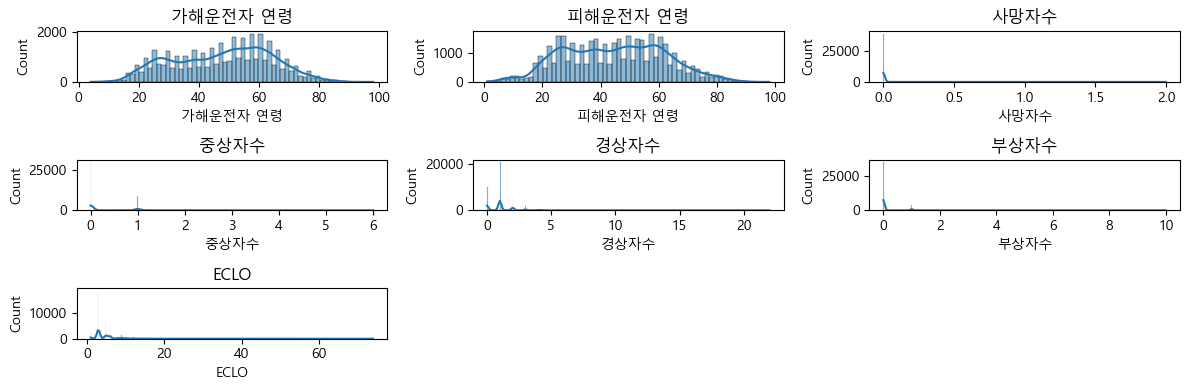

In [90]:
# 수치적 특성
# 문자열 데이터가 아닌 컬러만 모인 리스트 num_cols 를 이용해서 각컬럼별 분포를 확인
# 수치형 데이터들을 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
print(font_name) # Malgun Gothic
rc('font', family=font_name)

num_cols = train.select_dtypes(exclude='object').columns.to_list()  # 컬럼 중에서 object 객체인 컬럼들을 num_cols 리스트에 담는다.
plt.figure(figsize=(12,4))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(train[col], kde=True) # ^ kde : 부드러운 곡선으 표시할지 여부
    plt.title(col)                      # 각 subplot에 컬럼 이름 표시
plt.tight_layout()
plt.show()

In [91]:
# 범주형 데이터 확인
category_cols = train.select_dtypes(include='object').columns
len(category_cols)

16

In [92]:

# ID와 사고일시 컬럼 제외 14개의 컬럼으로 시작
category_cols = train.select_dtypes(include='object').columns[2:]
print(category_cols)

Index(['요일', '기상상태', '시군구', '도로형태', '노면상태', '사고유형', '사고유형 - 세부분류', '법규위반',
       '가해운전자 차종', '가해운전자 성별', '가해운전자 상해정도', '피해운전자 차종', '피해운전자 성별',
       '피해운전자 상해정도'],
      dtype='object')


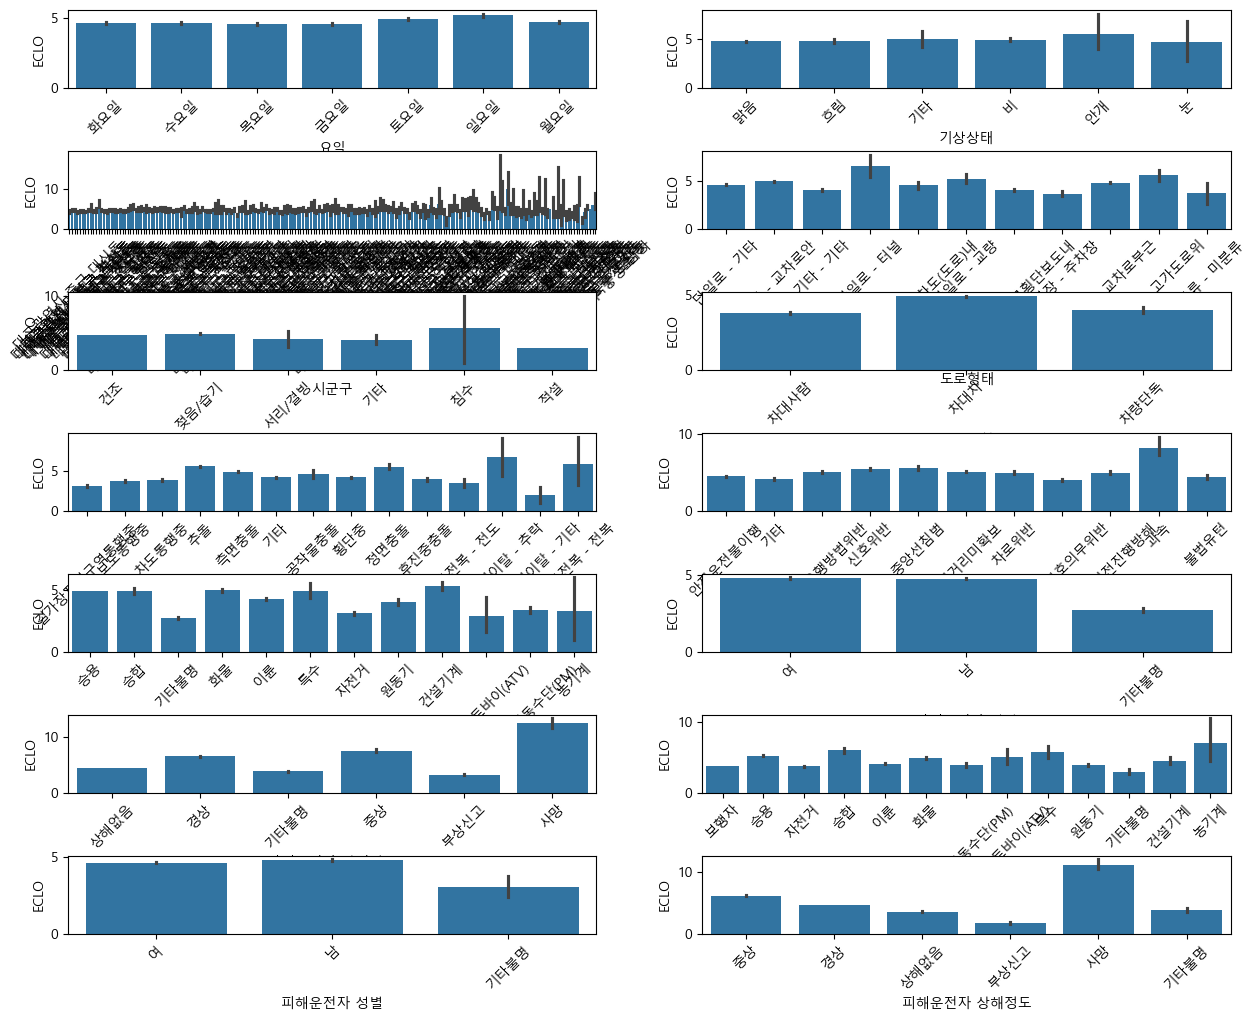

In [93]:
# 범주형 데이터 시각화
plt.figure(figsize=(15,12))

# 카테고리 많으면 자동 확대 설정 ^
# n_cat = len(train[col].unique())
# plt.figure(figsize=(max(8, n_cat * 0.6), 4))

for i, col in enumerate(category_cols):
    plt.subplot(7,2,i+1)
    sns.barplot(data=train,x=col,y='ECLO') # ECLO 심각도 ^
    plt.xticks(rotation=45) # 라벨 기울기 45도 
plt.tight_layout

plt.subplots_adjust(hspace=0.8)  # ← 그래프 세로 간격 넓히기 (0.5~1.0 사이 시도)

In [94]:
 # 사고 지역


In [95]:
# 시 군 구 의 정보를 가진 열컬럼을 구, 동을 나누어서 인명피해 심각도 ELCO 관계 탐색
train['구'] = train['시군구'].str.split(" ",expand=True)[1] # 빈칸으로 시군구를 분리하고 인덱스 1(구가 적혀져있는 항목)을 데이터프레임 형태로 반환
# expand=False (기본값) → 리스트로 반환
#  expand=True → 리스트의 각 요소를 **열(Column)**로 분리해서 DataFrame 형태로 반환
train['동'] = train['시군구'].str.split(" ",expand=True)[2] # 빈칸으로 시군구를 분리하고 인덱스 2(동이 적혀져있는 항목)을 데이터프레임 형태로 반환

#

C:\Users\Playdata2\AppData\Local\Temp\ipykernel_11760\1637158047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train,x='가해운전자 연령',y='법규위반',palette='deep')


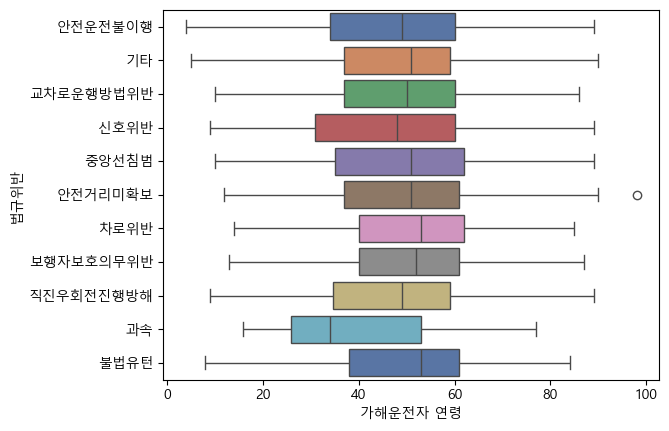

In [96]:
# 가해운전자의 연령 과 법규 위반 유형간의 관계 : boxplot
sns.boxplot(data=train,x='가해운전자 연령',y='법규위반',palette='deep')
plt.show()

# hue 파라미터가 어떤 상황에서 작동하고 어떤 상황에서는 막히는지를 설명해보자면,
# hue는 “범주에 따라 색을 나누는” 기능.
# 하지만 그래프의 축(y나 x)이 데이터가 있어야 색깔 표현이 가능하다.

<Axes: xlabel='가해운전자 연령', ylabel='ECLO'>

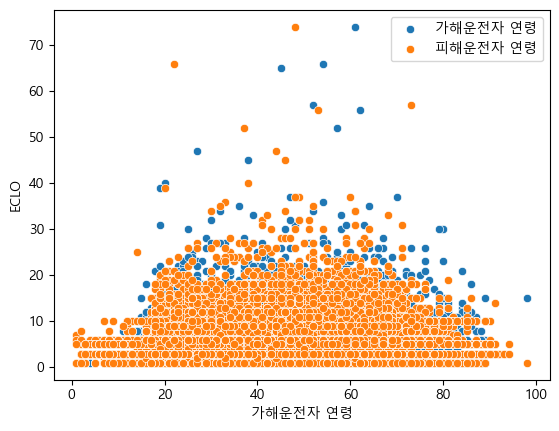

In [97]:
# 가해운전자 연령 : 피해운전자 연령 에 대해 피해 심각도(ECLO)의 관계 분석
# 가설피해 운전자 또는 피해운전자의연령이 높을수록 더 높은 ECLO값이 나올것으로 예상
sns.scatterplot(data=train,x='가해운전자 연령',y='ECLO',label='가해운전자 연령')
sns.scatterplot(data=train,x='피해운전자 연령',y='ECLO',label='피해운전자 연령')

In [98]:
# 타켓 변수 ECLO에 대한 연도 월 시간별시계열 그래프 확인 분석
# 가설 1 : 년도가 증가 할수록 ECLO 낮을 거 같다
# 가설 2 : 공휴일에는  ECLO 높은 거 같다
# 가설 3 : 출퇴근시간에 ECLO 높은 가 같다

# 사고 일시 컬럼에서 년도 월 일시간을 분류해서 추가
# 년도 line
# 월 bar
# 시간 line

In [99]:
# 학생풀이
# 타켓 변수 ECLO에 대한 연도 월 시간별 시계열 그래프 확인 분석


In [100]:
type(train['사고일시'][15]) # 타입 str, strip사용
print(train['사고일시'][15])

2019-01-01 19


In [101]:
# 연도 월 시간 분류하기
train['연도'] = train['사고일시'].str.split("-",expand=True)[0]
train['월'] = train['사고일시'].str.split("-",expand=True)[1]
index_2 = train['사고일시'].str.split("-",expand=True)[2]
train['일'] = index_2.str.split(" ",expand=True)[0]
train['시간'] = index_2.str.split(" ",expand=True)[1]

In [102]:
train['연도'].head()

0    2019
1    2019
2    2019
3    2019
4    2019
Name: 연도, dtype: object

In [103]:
train['월'].head()

0    01
1    01
2    01
3    01
4    01
Name: 월, dtype: object

In [104]:
train['일'].head()

0    01
1    01
2    01
3    01
4    01
Name: 일, dtype: object

In [105]:
train['시간'].head()

0    00
1    00
2    01
3    02
4    04
Name: 시간, dtype: object

In [106]:
# 시계열 데이터 만들기
import pandas as pd

hour_df = pd.DataFrame({'hour': train['시간']})

In [107]:
# train['Year'] =  pd.to_datetime(train.Dates).dt.year
# train['Month'] =  pd.to_datetime(train.Dates).dt.month
# train['Day'] =  pd.to_datetime(train.Dates).dt.day
# train['Hour'] =  pd.to_datetime(train.Dates).dt.hour
# train['Minute'] =  pd.to_datetime(train.Dates).dt.minute

# train = train.drop(columns=['Dates'])

In [117]:
numeric_coulmns = list(train.describe().columns)
numeric_coulmns

['가해운전자 연령', '피해운전자 연령', '사망자수', '중상자수', '경상자수', '부상자수', 'ECLO']

In [118]:
train_numeric_data =train[numeric_coulmns]

c:\김지은\파이썬_src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()


<Axes: >

c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


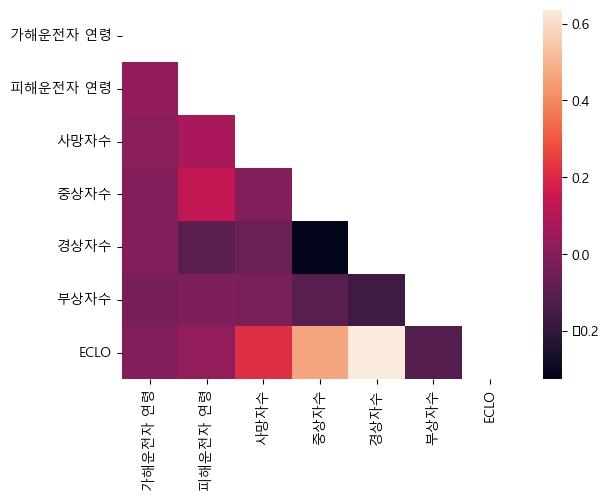

In [125]:
# 상관관계 heatmap
corr = train_numeric_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
# np.triu() ^ np.triu()는 행렬의 상삼각 부분만 남기고 나머지를 0으로 만드는 함수
# k 파라미터로 대각선 위치 조정 가능 (k=0 기본, k>0 위쪽, k<0 아래쪽)
# 주로 상관관계 히트맵 마스크나 상삼각 행렬 추출에 사용됨.

sns.heatmap(data=train_numeric_data.corr(),mask=mask)